#📌 Extracción

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


(7267, 6)

In [4]:
from pandas import json_normalize

df = json_normalize(df.to_dict(orient='records'))
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

Viendo la info y tipos

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [6]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [7]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

Revisando si hay nulos

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

Viendo los datos de las columnas

In [11]:
for col in df.columns:
    print(col, df[col].unique())

customerID ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn ['No' 'Yes' '']
customer.gender ['Female' 'Male']
customer.SeniorCitizen [0 1]
customer.Partner ['Yes' 'No']
customer.Dependents ['Yes' 'No']
customer.tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService ['Yes' 'No']
phone.MultipleLines ['No' 'Yes' 'No phone service']
internet.InternetService ['DSL' 'Fiber optic' 'No']
internet.OnlineSecurity ['No' 'Yes' 'No internet service']
internet.OnlineBackup ['Yes' 'No' 'No internet service']
internet.DeviceProtection ['No' 'Yes' 'No internet service']
internet.TechSupport ['Yes' 'No' 'No internet service']
internet.StreamingTV ['Yes' 'No' 'No internet service']
internet.StreamingMovies ['No' 'Yes' 'No internet service']
account.Contract ['One year' 'M

In [12]:
df['account.Charges.Total'].dtype

dtype('O')

Convirtiendo a numerico

In [13]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [14]:
df['account.Charges.Total'].isnull().sum()

np.int64(11)

In [15]:
df[df['account.Charges.Total'].isnull()][['customer.tenure','account.Charges.Monthly']]

,customer.tenure,account.Charges.Monthly
975,0,56.05
1775,0,20.00
1955,0,61.90
2075,0,19.70
2232,0,20.25
2308,0,25.35
2930,0,73.35
3134,0,25.75
3203,0,52.55
4169,0,80.85


Resolviendo inconsistencia de datos

In [16]:
cols_fix = [
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies',
    'phone.MultipleLines'
]

for col in cols_fix:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

In [17]:
for col in df.columns:
    print(col, df[col].unique())

customerID ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn ['No' 'Yes' '']
customer.gender ['Female' 'Male']
customer.SeniorCitizen [0 1]
customer.Partner ['Yes' 'No']
customer.Dependents ['Yes' 'No']
customer.tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService ['Yes' 'No']
phone.MultipleLines ['No' 'Yes']
internet.InternetService ['DSL' 'Fiber optic' 'No']
internet.OnlineSecurity ['No' 'Yes']
internet.OnlineBackup ['Yes' 'No']
internet.DeviceProtection ['No' 'Yes']
internet.TechSupport ['Yes' 'No']
internet.StreamingTV ['Yes' 'No']
internet.StreamingMovies ['No' 'Yes']
account.Contract ['One year' 'Month-to-month' 'Two year']
account.PaperlessBilling ['Yes' 'No']
account.PaymentMethod ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'B

In [18]:
df.isna().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [19]:
df = df.dropna(subset=['account.Charges.Total'])

Renombrando las columnas ara mejor visualizacion

In [20]:
df = df.rename(columns={
    'customer.gender': 'Gender',
    'customer.SeniorCitizen': 'SeniorCitizen',
    'customer.Partner': 'Partner',
    'customer.Dependents': 'Dependents',
    'customer.tenure': 'Tenure',

    'phone.PhoneService': 'PhoneService',
    'phone.MultipleLines': 'MultipleLines',

    'internet.InternetService': 'InternetService',
    'internet.OnlineSecurity': 'OnlineSecurity',
    'internet.OnlineBackup': 'OnlineBackup',
    'internet.DeviceProtection': 'DeviceProtection',
    'internet.TechSupport': 'TechSupport',
    'internet.StreamingTV': 'StreamingTV',
    'internet.StreamingMovies': 'StreamingMovies',

    'account.Contract': 'Contract',
    'account.PaperlessBilling': 'PaperlessBilling',
    'account.PaymentMethod': 'PaymentMethod',
    'account.Charges.Monthly': 'MonthlyCharges',
    'account.Charges.Total': 'TotalCharges'
})

In [21]:
df.columns

Index(['customerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

Conviertiendo en binarios

In [22]:
bin_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

for col in bin_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [23]:
df['Gender'] = df['Gender'].map({'Female': 1, 'Male': 0})

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   Gender            7256 non-null   int64  
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   int64  
 5   Dependents        7256 non-null   int64  
 6   Tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   int64  
 8   MultipleLines     7256 non-null   int64  
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   int64  
 11  OnlineBackup      7256 non-null   int64  
 12  DeviceProtection  7256 non-null   int64  
 13  TechSupport       7256 non-null   int64  
 14  StreamingTV       7256 non-null   int64  
 15  StreamingMovies   7256 non-null   int64  
 16  Contract          7256 non-null   object 
 17  

In [25]:
for col in df.columns:
    print(col, df[col].unique())

customerID ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn ['No' 'Yes' '']
Gender [1 0]
SeniorCitizen [0 1]
Partner [1 0]
Dependents [1 0]
Tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42]
PhoneService [1 0]
MultipleLines [0 1]
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity [0 1]
OnlineBackup [1 0]
DeviceProtection [0 1]
TechSupport [1 0]
StreamingTV [1 0]
StreamingMovies [0 1]
Contract ['One year' 'Month-to-month' 'Two year']
PaperlessBilling [1 0]
PaymentMethod ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
MonthlyCharges [65.6  59.9  73.9  ... 91.75 68.8  67.85]
TotalCharges [ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]


Churn ['No' 'Yes' '']

In [26]:
df['Churn'] = df['Churn'].replace('', pd.NA)

In [27]:
df['Churn'].isna().sum()

np.int64(224)

In [28]:
df = df.dropna(subset=['Churn'])

In [29]:
df['Churn'].isna().sum()

np.int64(0)

Se encontraron 224 registros con valores faltantes en la variable Churn.
Dado que esta es la variable objetivo del análisis y no es posible inferir su valor de manera confiable, estos registros fueron eliminados para evitar sesgos en el análisis de evasión.

#📊 Carga y análisis

In [30]:
df.describe()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.495307,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2283.300441
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,2266.771362
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000


In [31]:
df[['Tenure','MonthlyCharges','TotalCharges']].describe()

,Tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


Al revisar las métricas descriptivas del dataset, se observa que los clientes permanecen en la empresa en promedio 32 meses, aunque la mediana es de 29 meses, lo que indica que existe una buena cantidad de clientes relativamente nuevos. De hecho, el 25% de los clientes tiene 9 meses o menos de antigüedad, mientras que también existe un grupo importante con más de 4 años en la compañía.

En cuanto a los cargos mensuales, el promedio es de 64.76, con valores que van desde 18.25 hasta 118.75. La desviación estándar es alta, lo que sugiere que los clientes contratan diferentes combinaciones de servicios, generando pagos mensuales muy variados.

Respecto al gasto total acumulado, la diferencia entre clientes es aún más marcada. Mientras algunos han gastado menos de 500, otros superan los 8000, lo que está directamente relacionado con el tiempo que llevan en la empresa.

En conjunto, estos resultados muestran que el tiempo de permanencia del cliente (Tenure) y el monto que paga mensualmente (MonthlyCharges) son variables que probablemente tengan un papel importante al momento de analizar la evasión de clientes.

Analizando CHURN

In [32]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [33]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


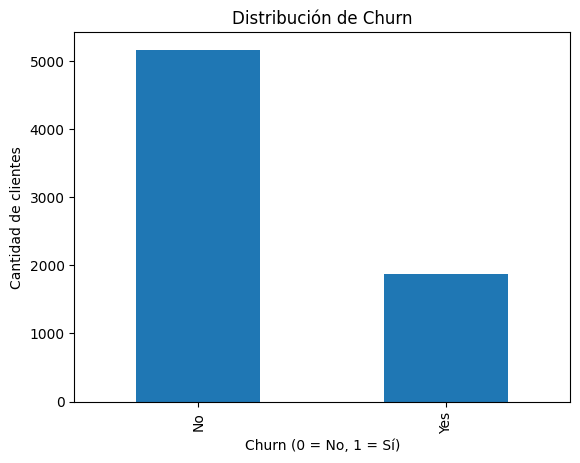

In [34]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title('Distribución de Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de clientes')
plt.show()

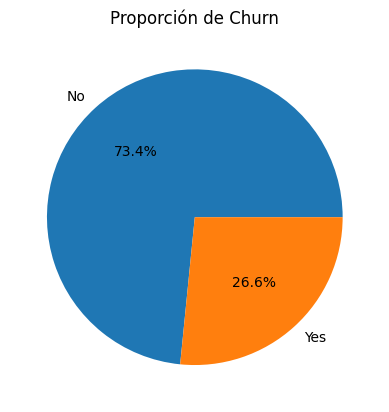

In [35]:

df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporción de Churn')
plt.ylabel('')
plt.show()

Cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago.

In [36]:
def churn_rate(col):
    return pd.crosstab(df[col], df['Churn'], normalize='index') * 100

In [37]:
def plot_churn(col):
    tabla = churn_rate(col)

    ax = tabla['Yes'].plot(kind='bar')

    plt.title(f'% de Churn por {col}')
    plt.ylabel('% Churn')
    plt.xlabel(col)

    for i, v in enumerate(tabla['Yes']):
        ax.text(i, v + 1, f'{v:.1f}%', ha='center')

    plt.show()

    return tabla

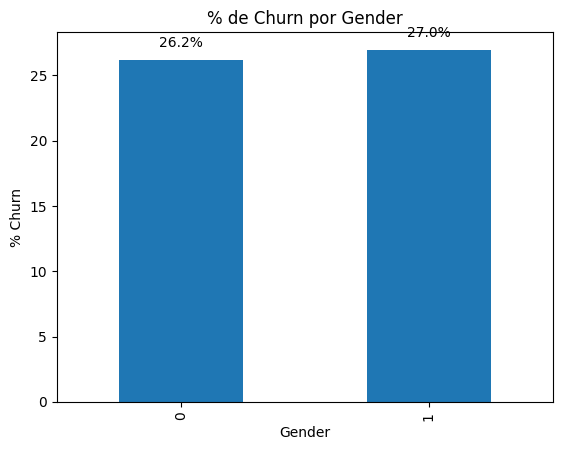

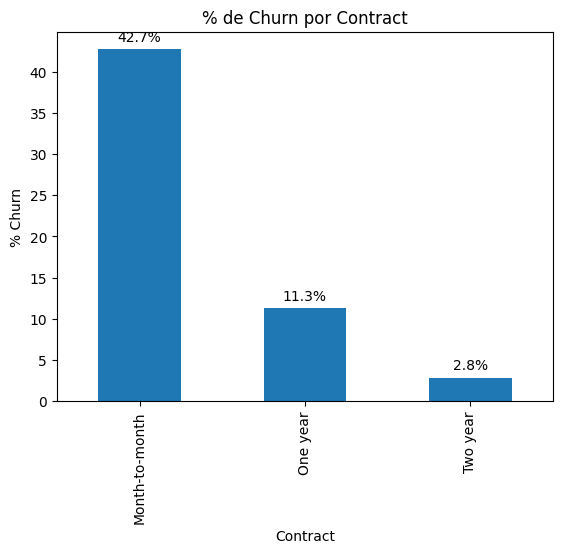

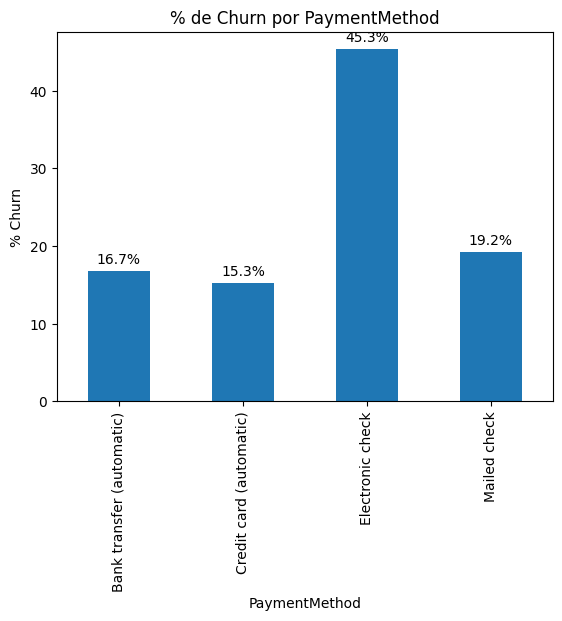

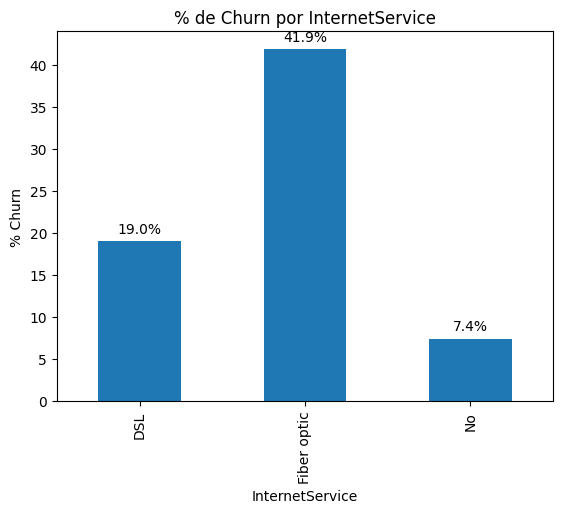

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [38]:
plot_churn('Gender')
plot_churn('Contract')
plot_churn('PaymentMethod')
plot_churn('InternetService')

In [39]:
churn_rate('Gender')

Churn,No,Yes
Gender,,
0,73.795435,26.204565
1,73.040482,26.959518


In [40]:
churn_rate('Contract')

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [41]:
churn_rate('PaymentMethod')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [42]:
churn_rate('InternetService')

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


Conteo de evasión por variables numéricas

In [43]:
df.groupby('Churn')[['Tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,Tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


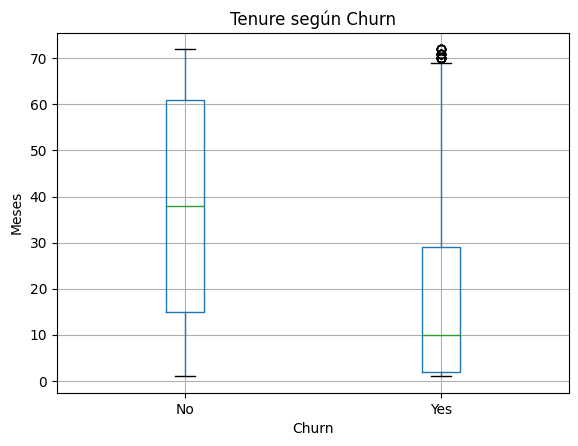

In [44]:

df.boxplot(column='Tenure', by='Churn')
plt.title('Tenure según Churn')
plt.suptitle('')
plt.ylabel('Meses')
plt.show()

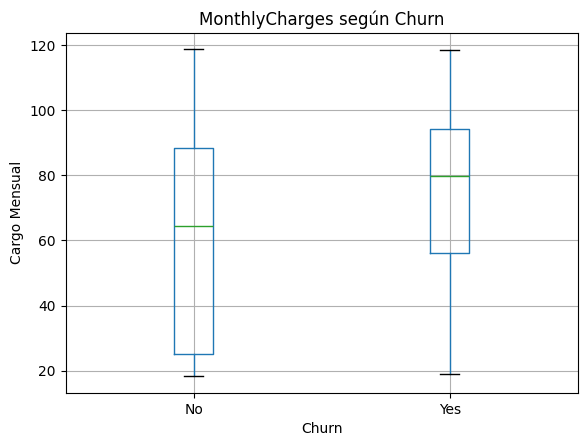

In [45]:
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('MonthlyCharges según Churn')
plt.suptitle('')
plt.ylabel('Cargo Mensual')
plt.show()

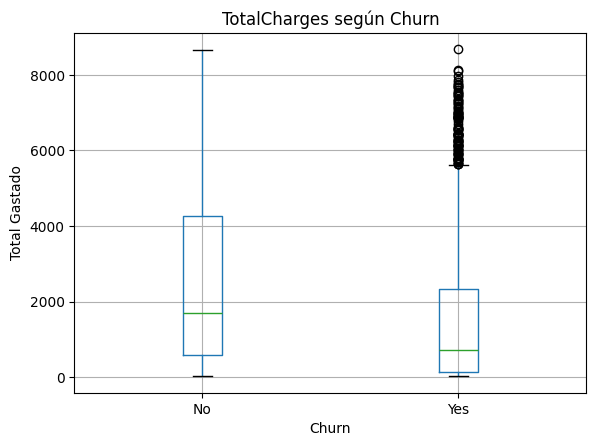

In [46]:
df.boxplot(column='TotalCharges', by='Churn')
plt.title('TotalCharges según Churn')
plt.suptitle('')
plt.ylabel('Total Gastado')
plt.show()

#📄Informe final

# 📊 INFORME FINAL — ANÁLISIS DE CHURN (Telecom X)

## 🔹 Introducción

El objetivo de este análisis es comprender los factores asociados a la evasión de clientes (Churn) en la empresa Telecom X. La evasión representa a los clientes que cancelan sus servicios, lo que impacta negativamente en los ingresos y la estabilidad del negocio.

A través del análisis de datos demográficos, características del servicio y comportamiento de consumo, se busca identificar patrones que permitan anticipar qué clientes tienen mayor probabilidad de abandonar la compañía. Estos insights pueden utilizarse para diseñar estrategias de retención más efectivas.

---

## 🔹 Limpieza y Tratamiento de Datos

Para preparar los datos para el análisis, se realizaron los siguientes pasos:

- Se cargaron los datos desde la API en formato JSON.
- Se transformaron en un DataFrame de Pandas para facilitar su manipulación.
- Se eliminaron registros duplicados.
- Se verificaron tipos de datos y valores inconsistentes.
- La columna **TotalCharges** fue convertida a formato numérico, ya que contenía valores no válidos.
- Se detectaron valores faltantes y se eliminaron los registros incompletos en dicha columna.
- Se estandarizaron variables categóricas convirtiendo valores como "Yes" y "No" a formato binario (1 y 0), facilitando el análisis.
- Se revisaron las categorías para garantizar consistencia en los datos.

Estas acciones aseguraron que el dataset estuviera limpio, coherente y listo para el análisis exploratorio.

---

## 🔹 Análisis Exploratorio de Datos (EDA)

Se analizaron tanto variables categóricas como numéricas para identificar patrones asociados al churn.

### 📊 Distribución general del churn

Se observó la proporción de clientes que permanecen frente a los que cancelan el servicio, permitiendo dimensionar la magnitud del problema.

---

### 📊 Variables categóricas

Se analizaron factores como género, tipo de contrato, método de pago y tipo de servicio de internet.

#### ✔ Género
No se observaron diferencias significativas entre hombres y mujeres, lo que indica que el género no influye de manera relevante en la evasión.

#### ✔ Tipo de contrato
Este fue el factor más determinante:

- Contrato mensual → tasa de churn muy alta (~43%)
- Contrato anual → tasa baja (~11%)
- Contrato de dos años → tasa muy baja (~3%)

Los clientes con contratos de largo plazo presentan mucha mayor fidelización.

#### ✔ Método de pago
El método **Electronic Check** mostró la mayor tasa de evasión (~45%), mientras que los pagos automáticos presentaron menor churn.

#### ✔ Servicio de internet
Los clientes con **fibra óptica** presentaron una tasa de cancelación significativamente mayor que los de DSL o sin servicio de internet.

---

### 📊 Variables numéricas

Se compararon valores promedio entre clientes que permanecen y los que cancelan.

#### ✔ Antigüedad (Tenure)
Los clientes que se van tienen aproximadamente la mitad de antigüedad que los que permanecen.

👉 Esto indica que los clientes nuevos son más propensos a cancelar.

#### ✔ Cargo mensual (MonthlyCharges)
Los clientes que cancelan pagan, en promedio, cargos mensuales más altos.

👉 Esto sugiere posible insatisfacción con el costo o con el valor percibido del servicio.

#### ✔ Total gastado (TotalCharges)
Los clientes que permanecen han gastado significativamente más, lo cual es coherente con su mayor tiempo de permanencia.

---

## 🔹 Conclusiones e Insights

El análisis permitió identificar varios factores fuertemente asociados al churn:

- Los clientes con contratos mensuales presentan la mayor probabilidad de cancelar.
- La baja antigüedad es un predictor clave de evasión.
- Los cargos mensuales elevados se asocian a mayor abandono.
- El servicio de fibra óptica muestra mayores tasas de cancelación.
- El método de pago Electronic Check está vinculado a alto churn.
- El género no influye de forma significativa.

En conjunto, estos resultados sugieren que los clientes nuevos con servicios costosos y bajo compromiso contractual son los más vulnerables a abandonar la empresa.

---

## 🔹 Recomendaciones Estratégicas

### 🎯 1. Incentivar contratos a largo plazo
Ofrecer descuentos o beneficios por contratar planes anuales o bianuales para reducir la tasa de cancelación.

### 🎯 2. Mejorar la experiencia de clientes nuevos
Implementar programas de onboarding, soporte prioritario o beneficios iniciales durante los primeros meses.

### 🎯 3. Revisar la percepción de valor en planes de alto costo
Evaluar si los clientes de fibra óptica perciben el servicio como acorde al precio pagado.

### 🎯 4. Promover métodos de pago automáticos
Fomentar el uso de tarjetas o transferencias automáticas, que presentan menor churn.

### 🎯 5. Implementar modelos predictivos de riesgo
Utilizar los factores identificados para anticipar clientes con alta probabilidad de abandono y actuar preventivamente.

---

## 🚀 Conclusión General

La evasión de clientes en Telecom X está principalmente asociada al nivel de compromiso contractual, la antigüedad y el costo del servicio. Mediante estrategias enfocadas en retención temprana y fidelización, la empresa puede reducir significativamente la pérdida de clientes y mejorar su rentabilidad a largo plazo.